In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, roc_auc_score, classification_report

pd.set_option('display.max_columns', None)

In [4]:
df = pd.read_csv('../data/cleaned/Telco-Customer-Churn-Cleaned.csv')
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn,TenureGroup,ChargeGroup,EST Annual Value,Churn Flag,Revenue At Risk
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No,0-12 Months,Low (<$35),358.2,0,0.0
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,No,25-48 Months,Medium ($35-$70),683.4,0,0.0
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes,0-12 Months,Medium ($35-$70),646.2,1,646.2
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No,25-48 Months,Medium ($35-$70),507.6,0,0.0
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes,0-12 Months,High (>$70),848.4,1,848.4


In [5]:
print("Shape:", df.shape)
print("\nData types:\n", df.dtypes)
print("\nMissing values:\n", df.isnull().sum().sum())
print("\nDuplicate rows:", df.duplicated().sum())

Shape: (7043, 26)

Data types:
 customerID           object
gender               object
SeniorCitizen         int64
Partner              object
Dependents           object
tenure                int64
PhoneService         object
MultipleLines        object
InternetService      object
OnlineSecurity       object
OnlineBackup         object
DeviceProtection     object
TechSupport          object
StreamingTV          object
StreamingMovies      object
Contract             object
PaperlessBilling     object
PaymentMethod        object
MonthlyCharges      float64
TotalCharges        float64
Churn                object
TenureGroup          object
ChargeGroup          object
EST Annual Value    float64
Churn Flag            int64
Revenue At Risk     float64
dtype: object

Missing values:
 0

Duplicate rows: 0


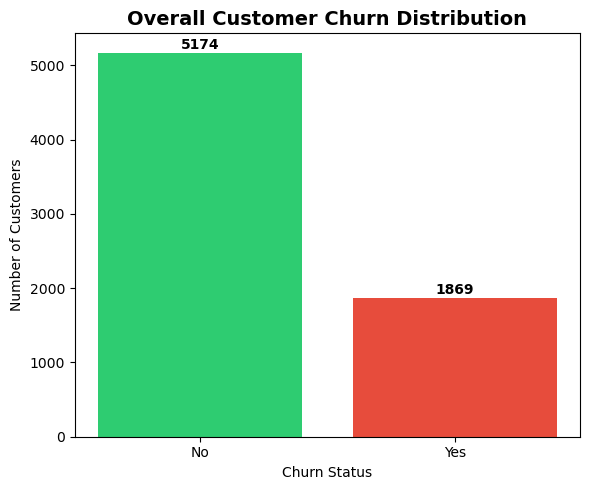

In [10]:
plt.figure(figsize=(6,5))
churn_counts = df['Churn'].value_counts()
colors = ['#2ecc71', '#e74c3c']
plt.bar(churn_counts.index, churn_counts.values, color=colors)
plt.title('Overall Customer Churn Distribution', fontsize=14, fontweight='bold')
plt.xlabel('Churn Status')
plt.ylabel('Number of Customers')
for i, v in enumerate(churn_counts.values):
    plt.text(i, v + 50, str(v), ha='center', fontweight='bold')
plt.tight_layout()
plt.savefig('../images/python_churn_distribution.png', dpi=150)
plt.show()

In [12]:
import os
print("Current working directory:", os.getcwd())
print("Does ../images exist?:", os.path.exists('../images'))
print("Contents of parent folder:", os.listdir('..'))

Current working directory: D:\8 Weeks Study plan\customer-churn-analytics\Python
Does ../images exist?: True
Contents of parent folder: ['Data', 'Excel', 'images', 'Power BI', 'Python', 'Reports', 'SQL']


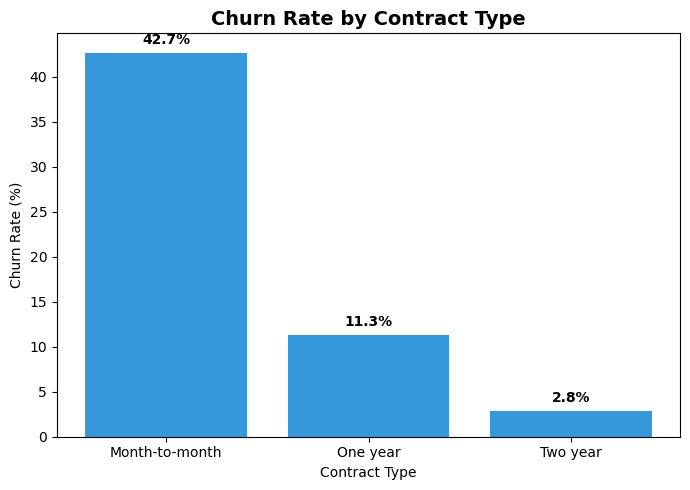

In [13]:
plt.figure(figsize=(7,5))
contract_churn = df.groupby('Contract')['Churn Flag'].mean() * 100
contract_churn = contract_churn.sort_values(ascending=False)
plt.bar(contract_churn.index, contract_churn.values, color='#3498db')
plt.title('Churn Rate by Contract Type', fontsize=14, fontweight='bold')
plt.xlabel('Contract Type')
plt.ylabel('Churn Rate (%)')
for i, v in enumerate(contract_churn.values):
    plt.text(i, v + 1, f'{v:.1f}%', ha='center', fontweight='bold')
plt.tight_layout()
plt.savefig('../images/python_churn_by_contract.png', dpi=150)
plt.show()

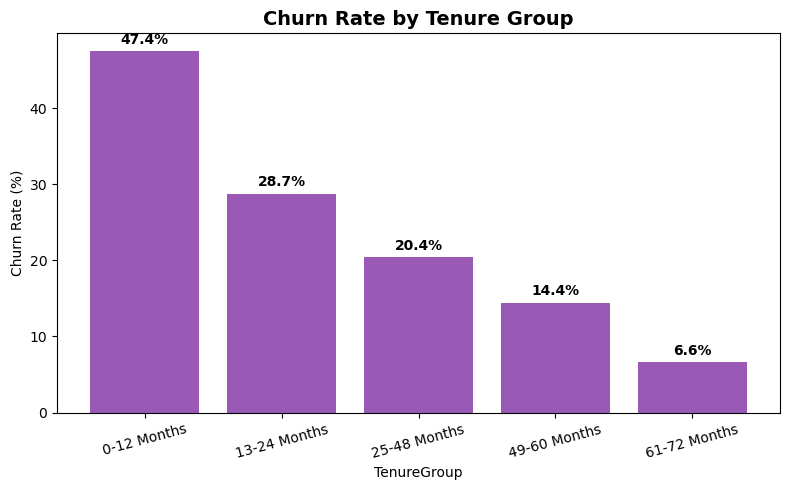

In [15]:
plt.figure(figsize=(8,5))
tenure_order = ['0-12 Months', '13-24 Months', '25-48 Months', '49-60 Months', '61-72 Months']
tenure_churn = df.groupby('TenureGroup')['Churn Flag'].mean().reindex(tenure_order) * 100
plt.bar(tenure_churn.index, tenure_churn.values, color='#9b59b6')
plt.title('Churn Rate by Tenure Group', fontsize=14, fontweight='bold')
plt.xlabel('TenureGroup')
plt.ylabel('Churn Rate (%)')
plt.xticks(rotation=15)
for i, v in enumerate(tenure_churn.values):
    plt.text(i, v + 1, f'{v:.1f}%', ha='center', fontweight='bold')
plt.tight_layout()
plt.savefig('../images/python_churn_by_tenure.png', dpi=150)
plt.show()

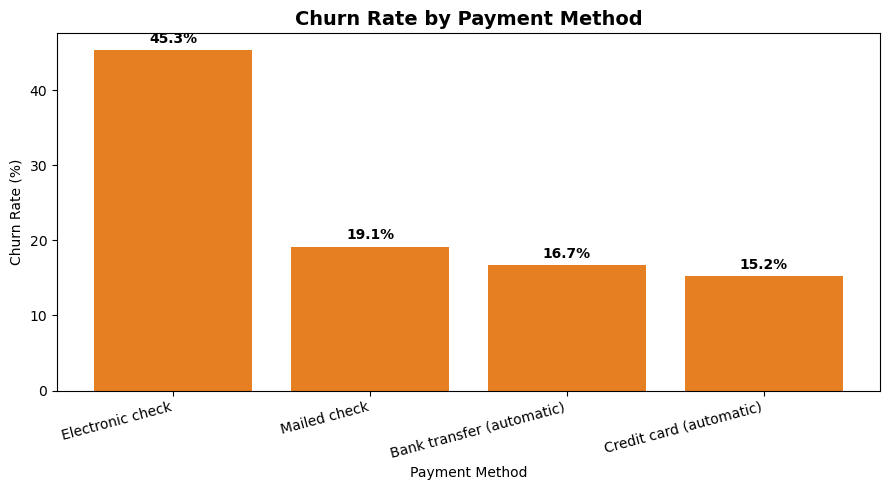

In [16]:
plt.figure(figsize=(9,5))
payment_churn = df.groupby('PaymentMethod')['Churn Flag'].mean().sort_values(ascending=False) * 100
plt.bar(payment_churn.index, payment_churn.values, color='#e67e22')
plt.title('Churn Rate by Payment Method', fontsize=14, fontweight='bold')
plt.xlabel('Payment Method')
plt.ylabel('Churn Rate (%)')
plt.xticks(rotation=15, ha='right')
for i, v in enumerate(payment_churn.values):
    plt.text(i, v + 1, f'{v:.1f}%', ha='center', fontweight='bold')
plt.tight_layout()
plt.savefig('../images/python_churn_by_payment.png', dpi=150)
plt.show()

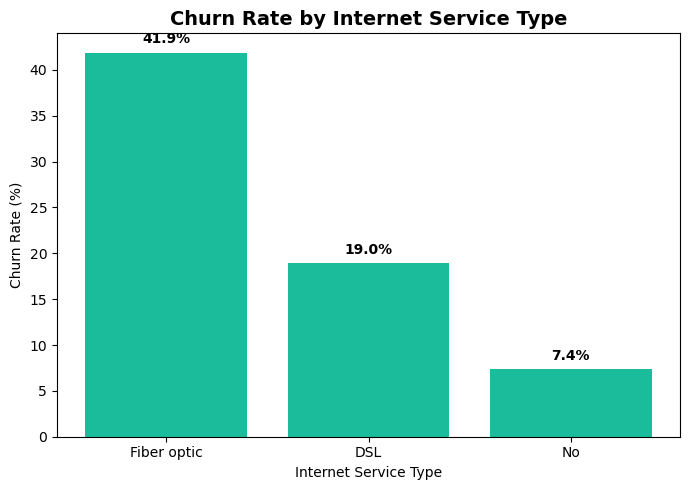

In [17]:
plt.figure(figsize=(7,5))
internet_churn = df.groupby('InternetService')['Churn Flag'].mean().sort_values(ascending=False) * 100
plt.bar(internet_churn.index, internet_churn.values, color='#1abc9c')
plt.title('Churn Rate by Internet Service Type', fontsize=14, fontweight='bold')
plt.xlabel('Internet Service Type')
plt.ylabel('Churn Rate (%)')
for i, v in enumerate(internet_churn.values):
    plt.text(i, v + 1, f'{v:.1f}%', ha='center', fontweight='bold')
plt.tight_layout()
plt.savefig('../images/python_churn_by_internet.png', dpi=150)
plt.show()

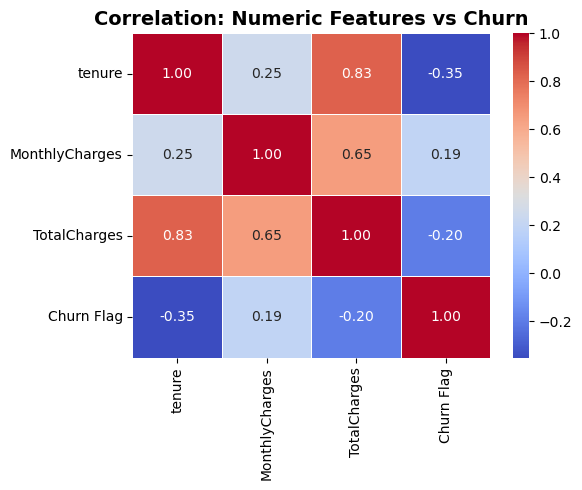

In [18]:
plt.figure(figsize=(6,5))
numeric_cols = ['tenure', 'MonthlyCharges', 'TotalCharges', 'Churn Flag']
corr_matrix = df[numeric_cols].corr()
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title('Correlation: Numeric Features vs Churn', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('../images/python_correlation_heatmap.png', dpi=150)
plt.show()

In [21]:
# Target: what we're predicting
y = df['Churn Flag']

# Features: exclude ID, text-duplicate of target, and leakage/redundant derived columns
drop_cols = ['customerID', 'Churn', 'Churn Flag', 'Revenue At Risk', 'TenureGroup', 'ChargeGroup', 'EST Annual Value']
X = df.drop(columns=drop_cols)

# Convert remaining text categories (gender, Contract, PaymentMethod, etc.) into numeric 0/1 columns
X = pd.get_dummies(X, drop_first=True)

print("Features shape:", X.shape)
print("Target shape:", y.shape)
X.head()

Features shape: (7043, 30)
Target shape: (7043,)


,SeniorCitizen,tenure,MonthlyCharges,TotalCharges,gender_Male,Partner_Yes,Dependents_Yes,PhoneService_Yes,MultipleLines_No phone service,MultipleLines_Yes,InternetService_Fiber optic,InternetService_No,OnlineSecurity_No internet service,OnlineSecurity_Yes,OnlineBackup_No internet service,OnlineBackup_Yes,DeviceProtection_No internet service,DeviceProtection_Yes,TechSupport_No internet service,TechSupport_Yes,StreamingTV_No internet service,StreamingTV_Yes,StreamingMovies_No internet service,StreamingMovies_Yes,Contract_One year,Contract_Two year,PaperlessBilling_Yes,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
0,0,1,29.85,29.85,False,True,False,False,True,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,True,False,True,False
1,0,34,56.95,1889.50,True,False,False,True,False,False,False,False,False,True,False,False,False,True,False,False,False,False,False,False,True,False,False,False,False,True
2,0,2,53.85,108.15,True,False,False,True,False,False,False,False,False,True,False,True,False,False,False,False,False,False,False,False,False,False,True,False,False,True
3,0,45,42.30,1840.75,True,False,False,False,True,False,False,False,False,True,False,False,False,True,False,True,False,False,False,False,True,False,False,False,False,False
4,0,2,70.70,151.65,False,False,False,True,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,True,False


In [22]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print("Training set:", X_train.shape)
print("Test set:", X_test.shape)
print("\nChurn rate in training set:", round(y_train.mean()*100, 1), "%")
print("Churn rate in test set:", round(y_test.mean()*100, 1), "%")

Training set: (5634, 30)
Test set: (1409, 30)

Churn rate in training set: 26.5 %
Churn rate in test set: 26.5 %


In [23]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

log_model = LogisticRegression(max_iter=1000, random_state=42)
log_model.fit(X_train_scaled, y_train)

log_preds = log_model.predict(X_test_scaled)

print("Logistic Regression trained successfully")
print("Predictions made on", len(log_preds), "test customers")

Logistic Regression trained successfully
Predictions made on 1409 test customers


In [24]:
rf_model = RandomForestClassifier(n_estimators=200, max_depth=10, random_state=42)
rf_model.fit(X_train, y_train)

rf_preds = rf_model.predict(X_test)

print("Random Forest trained successfully")
print("Predictions made on", len(rf_preds), "test customers")

Random Forest trained successfully
Predictions made on 1409 test customers


In [25]:
log_auc = roc_auc_score(y_test, log_model.predict_proba(X_test_scaled)[:,1])
rf_auc = roc_auc_score(y_test, rf_model.predict_proba(X_test)[:,1])

results = pd.DataFrame({
    'Metric': ['Accuracy', 'Precision', 'Recall', 'F1-Score', 'ROC-AUC'],
    'Logistic Regression': [
        accuracy_score(y_test, log_preds),
        precision_score(y_test, log_preds),
        recall_score(y_test, log_preds),
        f1_score(y_test, log_preds),
        log_auc
    ],
    'Random Forest': [
        accuracy_score(y_test, rf_preds),
        precision_score(y_test, rf_preds),
        recall_score(y_test, rf_preds),
        f1_score(y_test, rf_preds),
        rf_auc
    ]
})
results = results.round(3)
print(results)

      Metric  Logistic Regression  Random Forest
0   Accuracy                0.807          0.806
1  Precision                0.658          0.669
2     Recall                0.567          0.535
3   F1-Score                0.609          0.594
4    ROC-AUC                0.842          0.844


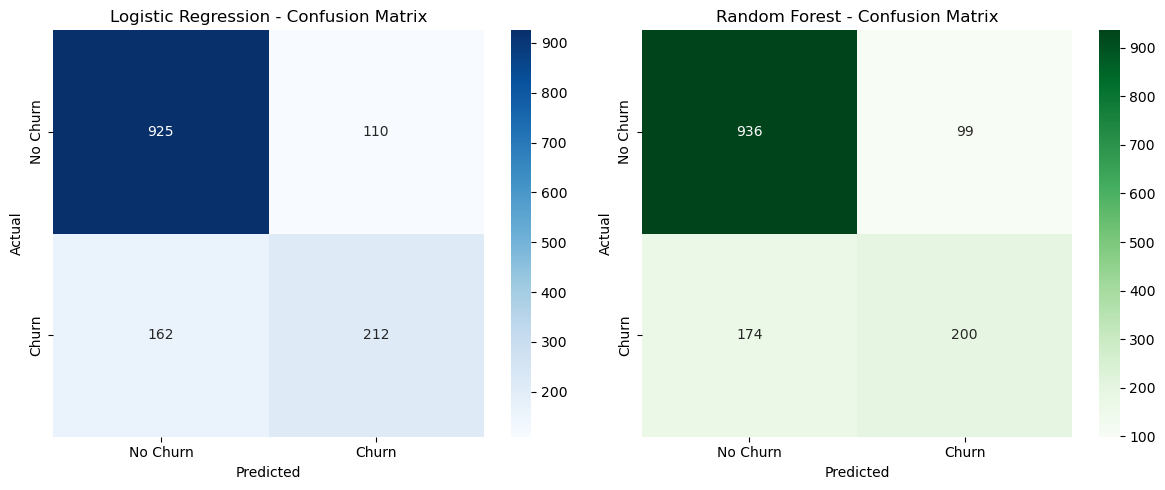

In [26]:
fig, axes = plt.subplots(1, 2, figsize=(12,5))

cm_log = confusion_matrix(y_test, log_preds)
sns.heatmap(cm_log, annot=True, fmt='d', cmap='Blues', ax=axes[0],
            xticklabels=['No Churn', 'Churn'], yticklabels=['No Churn', 'Churn'])
axes[0].set_title('Logistic Regression - Confusion Matrix')
axes[0].set_xlabel('Predicted')
axes[0].set_ylabel('Actual')

cm_rf = confusion_matrix(y_test, rf_preds)
sns.heatmap(cm_rf, annot=True, fmt='d', cmap='Greens', ax=axes[1],
            xticklabels=['No Churn', 'Churn'], yticklabels=['No Churn', 'Churn'])
axes[1].set_title('Random Forest - Confusion Matrix')
axes[1].set_xlabel('Predicted')
axes[1].set_ylabel('Actual')

plt.tight_layout()
plt.savefig('../images/python_confusion_matrices.png', dpi=150)
plt.show()

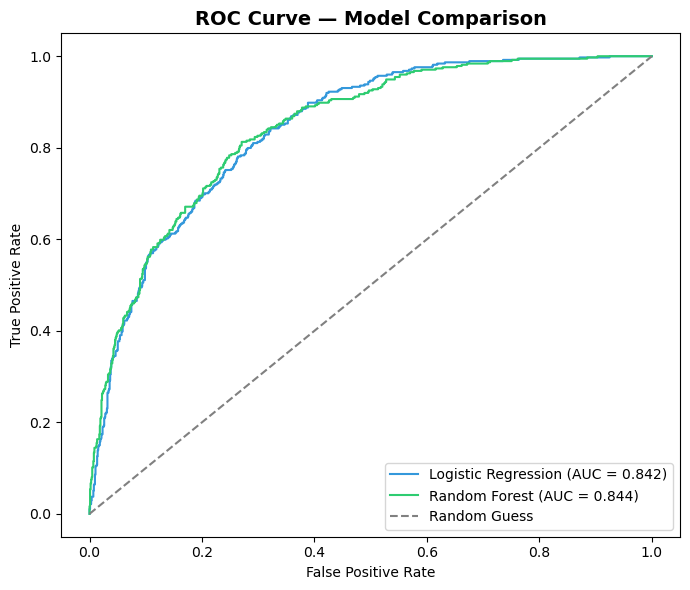

In [27]:
from sklearn.metrics import roc_curve

fpr_log, tpr_log, _ = roc_curve(y_test, log_model.predict_proba(X_test_scaled)[:,1])
fpr_rf, tpr_rf, _ = roc_curve(y_test, rf_model.predict_proba(X_test)[:,1])

plt.figure(figsize=(7,6))
plt.plot(fpr_log, tpr_log, label=f'Logistic Regression (AUC = {log_auc:.3f})', color='#3498db')
plt.plot(fpr_rf, tpr_rf, label=f'Random Forest (AUC = {rf_auc:.3f})', color='#2ecc71')
plt.plot([0,1], [0,1], linestyle='--', color='gray', label='Random Guess')
plt.title('ROC Curve — Model Comparison', fontsize=14, fontweight='bold')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.legend()
plt.tight_layout()
plt.savefig('../images/python_roc_curve.png', dpi=150)
plt.show()

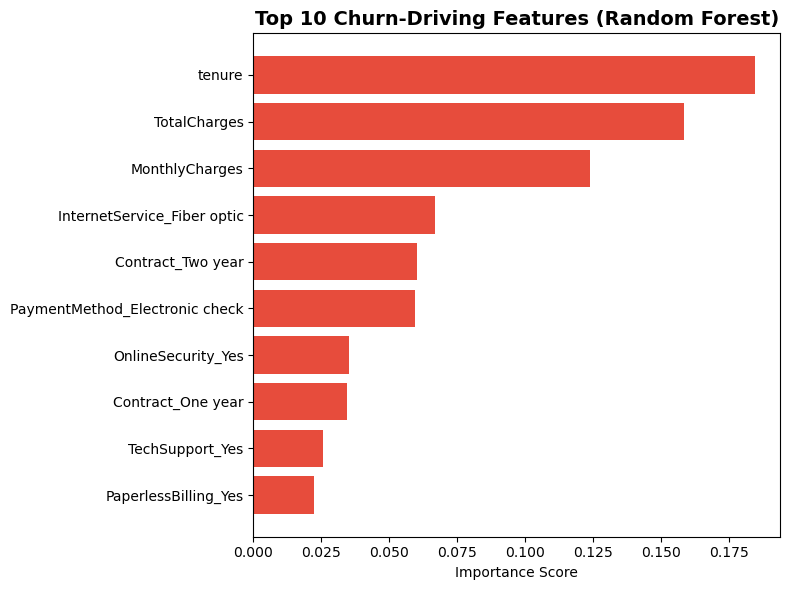

                           Feature  Importance
1                           tenure    0.184666
3                     TotalCharges    0.158575
2                   MonthlyCharges    0.123954
10     InternetService_Fiber optic    0.066907
25               Contract_Two year    0.060375
28  PaymentMethod_Electronic check    0.059619
13              OnlineSecurity_Yes    0.035278
24               Contract_One year    0.034364
19                 TechSupport_Yes    0.025770
26            PaperlessBilling_Yes    0.022349


In [28]:
importances = pd.DataFrame({
    'Feature': X.columns,
    'Importance': rf_model.feature_importances_
}).sort_values('Importance', ascending=False).head(10)

plt.figure(figsize=(8,6))
plt.barh(importances['Feature'], importances['Importance'], color='#e74c3c')
plt.title('Top 10 Churn-Driving Features (Random Forest)', fontsize=14, fontweight='bold')
plt.xlabel('Importance Score')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.savefig('../images/python_feature_importance.png', dpi=150)
plt.show()

print(importances)

In [29]:
import joblib

# Save both trained models and the scaler
joblib.dump(log_model, 'logistic_regression_model.pkl')
joblib.dump(rf_model, 'random_forest_model.pkl')
joblib.dump(scaler, 'scaler.pkl')

# Save evaluation metrics table
results.to_csv('../reports/model_evaluation_summary.csv', index=False)

# Save full feature importance ranking (not just top 10)
importances_full = pd.DataFrame({
    'Feature': X.columns,
    'Importance': rf_model.feature_importances_
}).sort_values('Importance', ascending=False)
importances_full.to_csv('../reports/feature_importance.csv', index=False)

print("Models and results saved successfully")

Models and results saved successfully
